## Understanding Your Dataset

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Name": ["Abid","Sara","John","Mina","David",
             "Emma","Alex","Sophia","Liam","Noah"],
    "Age": [22,21,23,22,24,21,23,22,24,21],
    "Gender": ["Male","Female","Male","Female","Male",
               "Female","Male","Female","Male","Male"],
    "Study_Hours": [10,15,8,12,18,20,7,16,14,11],
    "Marks": [85,92,78,88,95,97,72,90,84,80],
    "Attendance": [90,95,82,88,98,99,80,93,89,85]
})

In [2]:
df

,Name,Age,Gender,Study_Hours,Marks,Attendance
0,Abid,22,Male,10,85,90
1,Sara,21,Female,15,92,95
2,John,23,Male,8,78,82
3,Mina,22,Female,12,88,88
4,David,24,Male,18,95,98
5,Emma,21,Female,20,97,99
6,Alex,23,Male,7,72,80
7,Sophia,22,Female,16,90,93
8,Liam,24,Male,14,84,89
9,Noah,21,Male,11,80,85


In [3]:
df.head(5)

,Name,Age,Gender,Study_Hours,Marks,Attendance
0,Abid,22,Male,10,85,90
1,Sara,21,Female,15,92,95
2,John,23,Male,8,78,82
3,Mina,22,Female,12,88,88
4,David,24,Male,18,95,98


In [4]:
df.tail()

,Name,Age,Gender,Study_Hours,Marks,Attendance
5,Emma,21,Female,20,97,99
6,Alex,23,Male,7,72,80
7,Sophia,22,Female,16,90,93
8,Liam,24,Male,14,84,89
9,Noah,21,Male,11,80,85


In [5]:
df.shape

(10, 6)

In [6]:
df.columns

Index(['Name', 'Age', 'Gender', 'Study_Hours', 'Marks', 'Attendance'], dtype='str')

In [11]:
df.dtypes

Name             str
Age            int64
Gender           str
Study_Hours    int64
Marks          int64
Attendance     int64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         10 non-null     str  
 1   Age          10 non-null     int64
 2   Gender       10 non-null     str  
 3   Study_Hours  10 non-null     int64
 4   Marks        10 non-null     int64
 5   Attendance   10 non-null     int64
dtypes: int64(4), str(2)
memory usage: 612.0 bytes


In [8]:
df.describe()

,Age,Study_Hours,Marks,Attendance
count,10.000000,10.000000,10.000000,10.000000
mean,22.300000,13.100000,86.100000,89.900000
std,1.159502,4.254409,7.880355,6.436873
min,21.000000,7.000000,72.000000,80.000000
25%,21.250000,10.250000,81.000000,85.750000
50%,22.000000,13.000000,86.500000,89.500000
75%,23.000000,15.750000,91.500000,94.500000
max,24.000000,20.000000,97.000000,99.000000


In [13]:
df.describe(include="object")

C:\Users\HP\AppData\Local\Temp\ipykernel_6740\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Name,Gender
count,10,10
unique,10,2
top,Abid,Male
freq,1,6


In [14]:
df.index

RangeIndex(start=0, stop=10, step=1)

In [17]:
import pandas as pd
import numpy as np

dfe = pd.DataFrame({
    "Name": ["Abid", "Sara", None],
    "Age": [22, None, 25],
    "Marks": [90, 85, None]
})

In [24]:
dfe.isnull()

,Name,Age,Marks
0,False,False,False
1,False,True,False
2,True,False,True


In [22]:
dfe.isnull().sum().sum()

np.int64(3)

In [20]:
dfe.isnull().sum(axis=1)

0    0
1    1
2    2
dtype: int64

In [23]:
dfe.isnull().any()

Name     True
Age      True
Marks    True
dtype: bool

In [26]:
(dfe.isnull().sum() / len(df)) * 100

Name     20.0
Age      20.0
Marks    20.0
dtype: float64

In [ ]:
dfe.dropna() # rows with missing values will be dropped
# Returns a new DataFrame.The original df stays the same.
# to save it df = df.dropna() or df.dropna(inplace=True)

,Name,Age,Marks
0,Abid,22.0,90.0


In [31]:
dfe.dropna(axis=1) # columns with missing values will be dropped

""
0
1
2


Lesson 2: Missing Values (One of the Most Important EDA Lessons)

Welcome to the most important data cleaning lesson.

In real-world datasets, missing values are everywhere.

A dataset may have:

Empty cells
Unknown values
Null values
Missing information

If you ignore them, your Machine Learning model may produce poor results or even fail.

In [65]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name": ["Abid", "Sara", "John", "Mina", "David"],
    "Age": [22, 21, np.nan, 22, 24],
    "Study_Hours": [10, 15, 8, np.nan, 18],
    "Marks": [85, 92, 78, 88, np.nan]
})

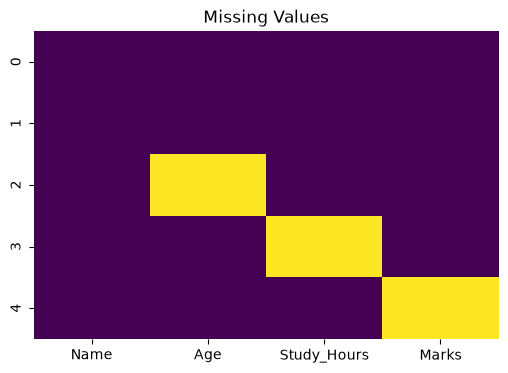

In [66]:
# A quick trick is to use a heatmap to know the missing values in the dataset. The yellow color indicates the missing values.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")

plt.show()

In [67]:
df.fillna(0) # fill missing values with 0

,Name,Age,Study_Hours,Marks
0,Abid,22.0,10.0,85.0
1,Sara,21.0,15.0,92.0
2,John,0.0,8.0,78.0
3,Mina,22.0,0.0,88.0
4,David,24.0,18.0,0.0


In [68]:
# Fill missing values and assign back
df["Name"] = df["Name"].fillna("Unknown")
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Marks"] = df["Marks"].fillna(df["Marks"].median())

# mode() returns a Series, so select the first mode
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].mode()[0])

# Print updated DataFrame
print(df)

    Name    Age  Study_Hours  Marks
0   Abid  22.00         10.0   85.0
1   Sara  21.00         15.0   92.0
2   John  22.25          8.0   78.0
3   Mina  22.00          8.0   88.0
4  David  24.00         18.0   86.5


In [69]:
# Forward fill: df.fillna(method="ffill")/df.ffill() :The missing values are filled with the previous valid value.
# Backward fill: df.fillna(method="bfill")/df.bfill() :The missing values are filled with the next valid value.
df

,Name,Age,Study_Hours,Marks
0,Abid,22.00,10.0,85.0
1,Sara,21.00,15.0,92.0
2,John,22.25,8.0,78.0
3,Mina,22.00,8.0,88.0
4,David,24.00,18.0,86.5


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.DataFrame({
    "Temperature": [30, 31, np.nan, np.nan, 35, 36],
    "City": ["Dhaka", "Dhaka", np.nan, "Chattogram", "Chattogram", "Khulna"]
})


In [76]:
print(df.isnull().sum())


Temperature    2
City           1
dtype: int64


In [77]:
filled_df = df.copy()

In [78]:
filled_df["Temperature"] = filled_df["Temperature"].ffill()
filled_df["City"] = filled_df["City"].fillna(
    filled_df["City"].mode()[0]
)


In [79]:
filled_df

,Temperature,City
0,30.0,Dhaka
1,31.0,Dhaka
2,31.0,Chattogram
3,31.0,Chattogram
4,35.0,Chattogram
5,36.0,Khulna


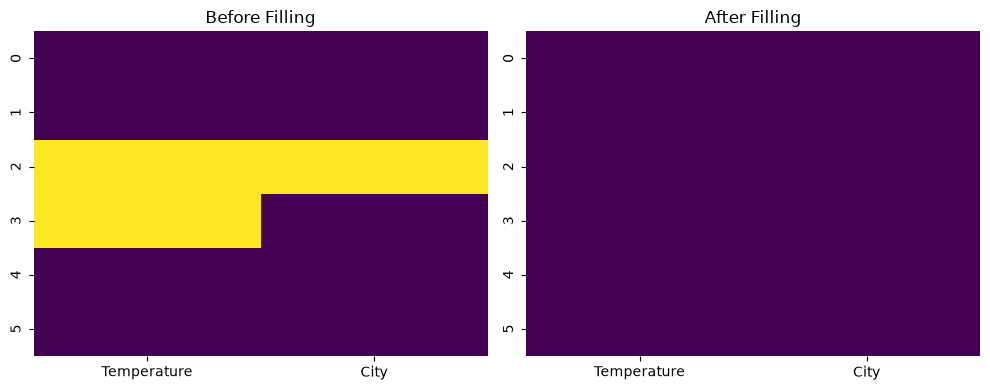

In [80]:
plt.figure(figsize=(10, 4))

# Before
plt.subplot(1, 2, 1)
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Before Filling")

# After
plt.subplot(1, 2, 2)
sns.heatmap(filled_df.isnull(), cbar=False, cmap="viridis")
plt.title("After Filling")

plt.tight_layout()
plt.show()

## Lesson 3: Duplicates, Incorrect Data & Data Types
In Lesson 2, we learned how to deal with missing values.

Today we'll learn another major part of data cleaning.

Finding and fixing bad data.

Real-world datasets often contain:

Duplicate rows
Wrong data types
Inconsistent text
Invalid values
Extra spaces

A professional data scientist always cleans these before building a machine learning model.

In [100]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name":[
        "Abid","Sara","John","Sara","Mina",
        "David","Abid"
    ],
    "Age":[
        "22","21","23","21","22",
        "Twenty Four","22"
    ],
    "Gender":[
        "Male","Female","male",
        "Female ","Female",
        "Male","Male"
    ],
    "Marks":[
        85,92,78,92,np.nan,95,85
    ]
})

print(df)

    Name          Age   Gender  Marks
0   Abid           22     Male   85.0
1   Sara           21   Female   92.0
2   John           23     male   78.0
3   Sara           21  Female    92.0
4   Mina           22   Female    NaN
5  David  Twenty Four     Male   95.0
6   Abid           22     Male   85.0


In [101]:
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6     True
dtype: bool

In [102]:
df.duplicated().sum()

np.int64(1)

In [103]:
df[df.duplicated()]

,Name,Age,Gender,Marks
6,Abid,22,Male,85.0


In [104]:
df=df.drop_duplicates()

In [105]:
df

,Name,Age,Gender,Marks
0,Abid,22,Male,85.0
1,Sara,21,Female,92.0
2,John,23,male,78.0
3,Sara,21,Female,92.0
4,Mina,22,Female,NaN
5,David,Twenty Four,Male,95.0


In [106]:
# Remove Duplicates Based on One Column
df.drop_duplicates(
    subset="Name"
) # If two rows have the same Name, only the first one remains.

,Name,Age,Gender,Marks
0,Abid,22,Male,85.0
1,Sara,21,Female,92.0
2,John,23,male,78.0
4,Mina,22,Female,NaN
5,David,Twenty Four,Male,95.0


In [107]:
# Keep Last Duplicate Instead ,default keep=first
df.drop_duplicates(
    keep="last"
)

,Name,Age,Gender,Marks
0,Abid,22,Male,85.0
1,Sara,21,Female,92.0
2,John,23,male,78.0
3,Sara,21,Female,92.0
4,Mina,22,Female,NaN
5,David,Twenty Four,Male,95.0


In [98]:
# remove all duplicates, keep=False
import pandas as pd
import numpy as np

dfe = pd.DataFrame({
    "Name":[
        "Abid","Sara","John","Sara","Mina",
        "David","Abid"
    ],
    "Age":[
        "22","21","23","21","22",
        "Twenty Four","22"
    ],
    "Gender":[
        "Male","Female","male",
        "Female ","Female",
        "Male","Male"
    ],
    "Marks":[
        85,92,78,92,np.nan,95,85
    ]
})

dfe.drop_duplicates(
    keep=False
)

,Name,Age,Gender,Marks
1,Sara,21,Female,92.0
2,John,23,male,78.0
3,Sara,21,Female,92.0
4,Mina,22,Female,NaN
5,David,Twenty Four,Male,95.0


In [108]:
df

,Name,Age,Gender,Marks
0,Abid,22,Male,85.0
1,Sara,21,Female,92.0
2,John,23,male,78.0
3,Sara,21,Female,92.0
4,Mina,22,Female,NaN
5,David,Twenty Four,Male,95.0


In [109]:
df.dtypes

Name          str
Age           str
Gender        str
Marks     float64
dtype: object

In [ ]:
# df["Age"] = df["Age"].astype(int) # will cause error


In [ ]:
df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce" # If a value can't be converted, replace it with NaN instead of raising an error.
)

In [113]:
df.dtypes

Name          str
Age       float64
Gender        str
Marks     float64
dtype: object

In [114]:
df["Gender"] = df["Gender"].str.lower()

In [115]:
df["Gender"] = df["Gender"].str.upper()

In [ ]:
df["Gender"] = df["Gender"].str.title() # Male, Female

In [117]:
df

,Name,Age,Gender,Marks
0,Abid,22.0,Male,85.0
1,Sara,21.0,Female,92.0
2,John,23.0,Male,78.0
3,Sara,21.0,Female,92.0
4,Mina,22.0,Female,NaN
5,David,NaN,Male,95.0


In [ ]:
df["Gender"] = df["Gender"].str.strip() # remove leading and trailing whitespace


In [ ]:
# Removes spaces.Converts to title case.
df["Gender"] = (
    df["Gender"]
      .str.strip()
      .str.title()
)

In [120]:
import pandas as pd

df = pd.DataFrame({
    "Name": ["Abid", "Sara", "John", "Mina", "David", "Alex", "Emma"],
    "Response": ["Y", "YES", "N", "Yes", "Y", "NO", "YES"]
})

df["Response"] = df["Response"].replace({
    "Y":"Yes",
    "YES":"Yes",
    "N":"No"
})

In [121]:
df

,Name,Response
0,Abid,Yes
1,Sara,Yes
2,John,No
3,Mina,Yes
4,David,Yes
5,Alex,NO
6,Emma,Yes


In [123]:
# df["Gender"] = df["Gender"].replace({
#     "M":"Male",
#     "male":"Male"
# })

In [ ]:
# Rename Columns
df["Gender"] = df["Gender"].replace({
    "M":"Male",
    "male":"Male"
})

In [ ]:
# save
df = df.rename(
    columns={
        "Study Hours":"Study_Hours"
    }
)

In [ ]:
# Rename multiple comumns
df = df.rename(columns={
    "Study Hours": "Study_Hours",
    "Final Marks": "Final_Marks"
})

In [ ]:
df["Gender"].unique() # ['Male','male','Female ','Female']

In [ ]:
# Count each unique value.
df["Gender"].value_counts()

In [124]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name":["Abid","Sara","John","Sara","Mina","David","Abid"],
    "Age":["22","21","23","21","22","Twenty Four","22"],
    "Gender":["Male","Female","male","Female ","Female","Male","Male"],
    "Marks":[85,92,78,92,np.nan,95,85]
})

# Remove duplicate rows
df = df.drop_duplicates()

# Clean Gender column
df["Gender"] = (
    df["Gender"]
      .str.strip()
      .str.title()
)

# Convert Age to numeric
df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
)

# Fill missing Age with median
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

# Fill missing Marks with mean
df["Marks"] = df["Marks"].fillna(
    df["Marks"].mean()
)

print(df)

    Name   Age  Gender  Marks
0   Abid  22.0    Male   85.0
1   Sara  21.0  Female   92.0
2   John  23.0    Male   78.0
3   Sara  21.0  Female   92.0
4   Mina  22.0  Female   88.4
5  David  22.0    Male   95.0


In [125]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    "Age": ["22", "21", "Twenty", "24", "18"],
    "Study Hours": [10, 12, 15, 20, 8]
})

# 1. Check the data types
print("Data Types Before Conversion:")
print(df.dtypes)

# 2. Convert Age to numeric
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# 3. Count the missing values created
print("\nMissing Values:")
print(df["Age"].isnull().sum())

# 4. Fill missing Age with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# 5. Rename the column
df.rename(columns={"Study Hours": "Study_Hours"}, inplace=True)

# 6. Display the cleaned DataFrame
print("\nCleaned DataFrame:")
print(df)

Data Types Before Conversion:
Age              str
Study Hours    int64
dtype: object

Missing Values:
1

Cleaned DataFrame:
    Age  Study_Hours
0  22.0           10
1  21.0           12
2  21.5           15
3  24.0           20
4  18.0            8


## Lesson 4: Univariate Analysis (Analyzing One Variable)
The word Univariate consists of two parts:

Uni = One
Variable = Column

So, Univariate Analysis means analyzing one column at a time.
You ignore every other column and ask:

What values does this column contain?
Is it evenly distributed?
What is the average?
Are there outliers?
Is it skewed?


In [1]:
import pandas as pd

df = pd.DataFrame({
    "Name":["Abid","Sara","John","Mina","David",
            "Emma","Alex","Sophia","Liam","Noah"],

    "Gender":["Male","Female","Male","Female",
              "Male","Female","Male","Female",
              "Male","Male"],

    "Age":[22,21,23,22,24,21,23,22,24,21],

    "Study_Hours":[10,15,8,12,18,20,7,16,14,11],

    "Marks":[85,92,78,88,95,97,72,90,84,80]
})

In [2]:
df["Marks"].describe()

count    10.000000
mean     86.100000
std       7.880355
min      72.000000
25%      81.000000
50%      86.500000
75%      91.500000
max      97.000000
Name: Marks, dtype: float64

In [4]:
df["Gender"].value_counts()

Gender
Male      6
Female    4
Name: count, dtype: int64

In [6]:
df["Gender"].value_counts(normalize=True) * 100

Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64

In [7]:
df["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [8]:
df["Gender"].nunique()

2

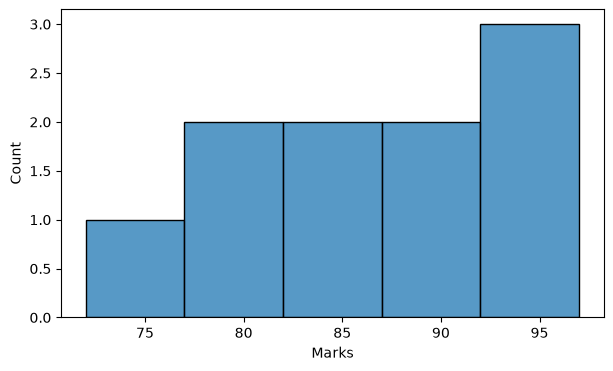

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="Marks",
    bins=5
)

plt.show()

<Axes: xlabel='Marks', ylabel='Density'>

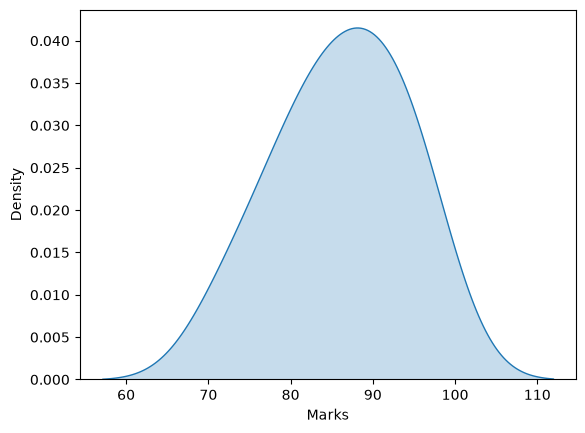

In [10]:
sns.kdeplot(
    data=df,
    x="Marks",
    fill=True
)

<Axes: xlabel='Marks', ylabel='Count'>

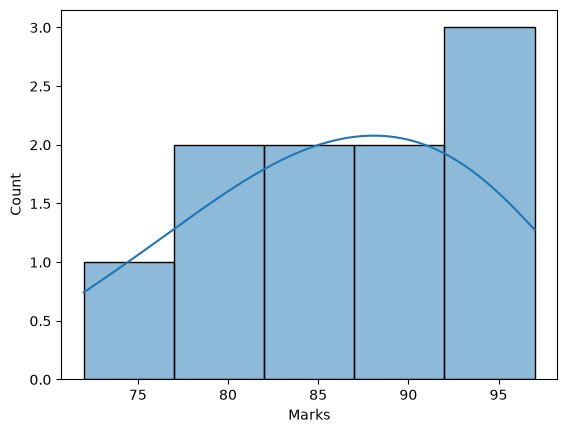

In [11]:
sns.histplot(
    data=df,
    x="Marks",
    kde=True
)

<Axes: xlabel='Marks'>

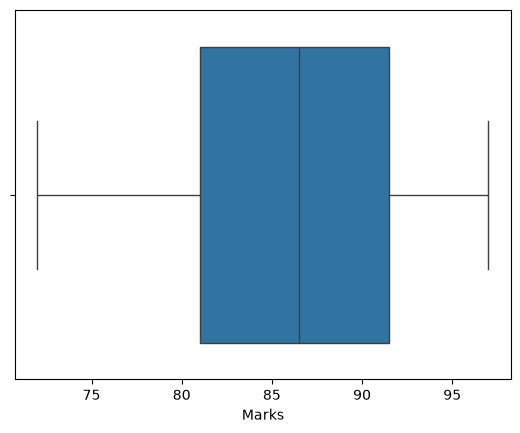

In [12]:
sns.boxplot(
    data=df,
    x="Marks"
)

<Axes: xlabel='Gender', ylabel='count'>

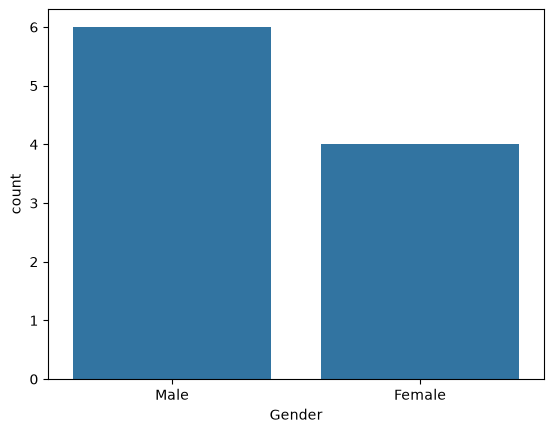

In [13]:
sns.countplot(
    data=df,
    x="Gender"
)

In [15]:
df["Gender"].value_counts() # count simply graphical version of it

Gender
Male      6
Female    4
Name: count, dtype: int64

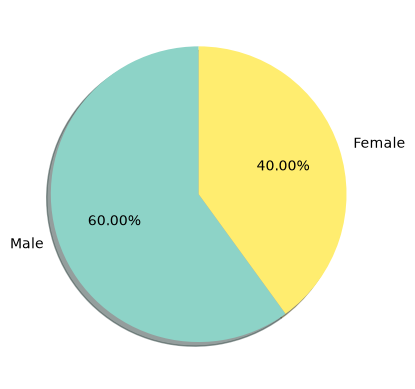

In [21]:
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    startangle=90,
    colormap="Set3",
    shadow=True
)

plt.ylabel("")
plt.show()

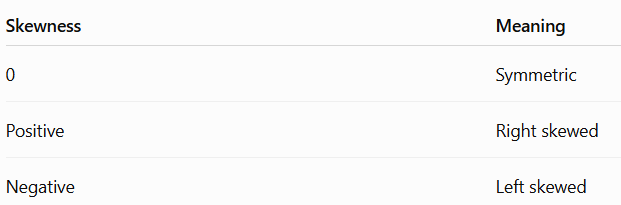

In [22]:
df["Marks"].skew()

np.float64(-0.3691480389554348)

In [24]:
# Kurtosis Measures how heavy the tails are. As a beginner, you don't need to memorize the interpretation. Just know that it describes the shape of the distribution beyond skewness.
df["Marks"].kurt()

np.float64(-0.5427870801625163)

count    10.000000
mean     86.100000
std       7.880355
min      72.000000
25%      81.000000
50%      86.500000
75%      91.500000
max      97.000000
Name: Marks, dtype: float64
Gender
Male      6
Female    4
Name: count, dtype: int64


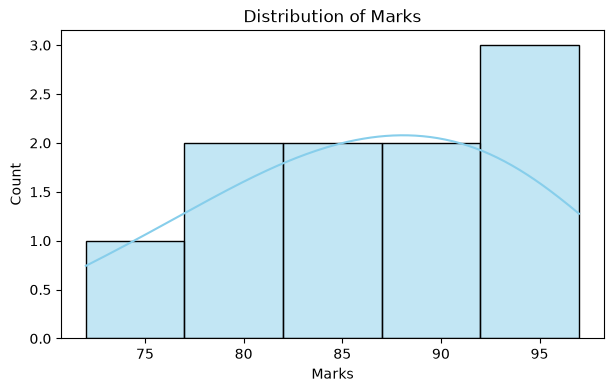

C:\Users\HP\AppData\Local\Temp\ipykernel_18220\479226436.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


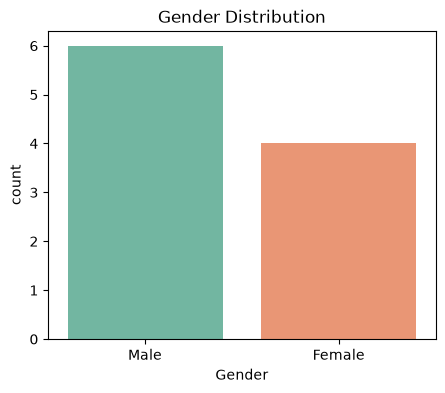

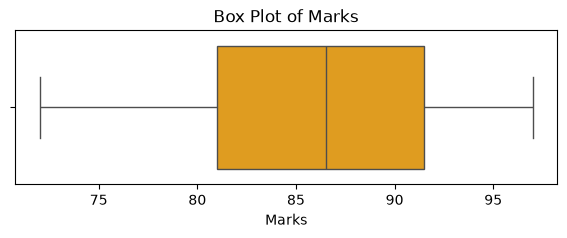

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Gender":["Male","Female","Male","Female",
              "Male","Female","Male","Female",
              "Male","Male"],

    "Marks":[85,92,78,88,95,97,72,90,84,80]
})

# Summary statistics
print(df["Marks"].describe())

# Value counts
print(df["Gender"].value_counts())

# Histogram
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="Marks",
    bins=5,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Marks")

plt.show()

# Count Plot
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="Gender",
    palette="Set2"
)

plt.title("Gender Distribution")

plt.show()

# Box Plot
plt.figure(figsize=(7,2))

sns.boxplot(
    data=df,
    x="Marks",
    color="orange"
)

plt.title("Box Plot of Marks")

plt.show()

Summary Statistics:
count    10.000000
mean     86.100000
std       7.880355
min      72.000000
25%      81.000000
50%      86.500000
75%      91.500000
max      97.000000
Name: Marks, dtype: float64

Skewness:
-0.3691480389554348

Kurtosis:
-0.5427870801625163


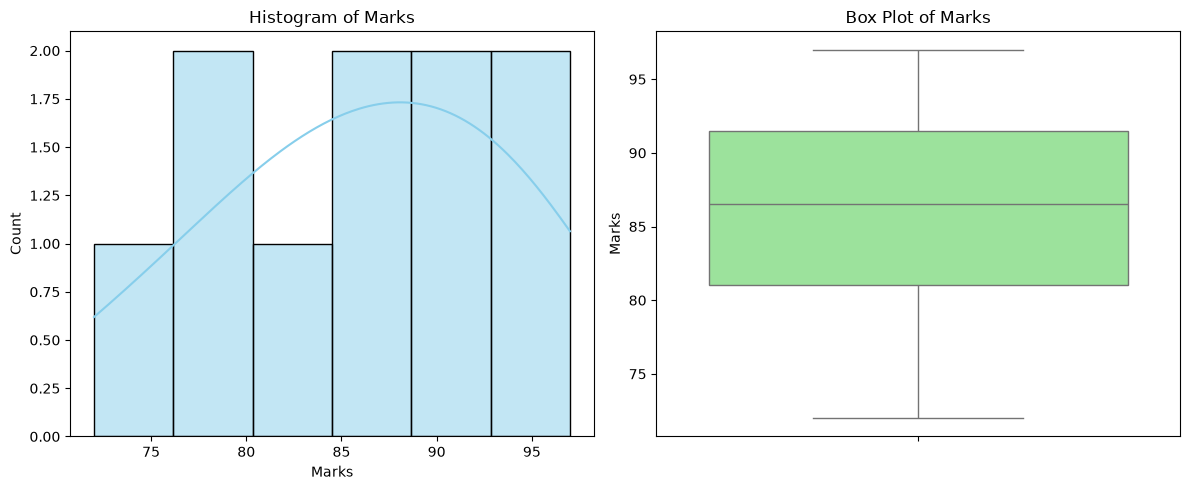

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary Statistics
print("Summary Statistics:")
print(df["Marks"].describe())

print("\nSkewness:")
print(df["Marks"].skew())

print("\nKurtosis:")
print(df["Marks"].kurt())

# 2. Create the plots
plt.figure(figsize=(12, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df["Marks"], bins=6, kde=True, color="skyblue")
plt.title("Histogram of Marks")

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Marks"], color="lightgreen")
plt.title("Box Plot of Marks")

plt.tight_layout()
plt.show()

## Lesson 5: Bivariate Analysis (Analyzing Two Variables)
The word Bivariate consists of two parts:

Bi = Two
Variable = Column

So,

Bivariate Analysis means studying the relationship between two columns.

Instead of asking,

"What does the Marks column look like?"

we ask,

"How are Study Hours and Marks related?"

In [27]:
import pandas as pd

df = pd.DataFrame({
    "Name":["Abid","Sara","John","Mina","David",
            "Emma","Alex","Sophia","Liam","Noah"],

    "Gender":["Male","Female","Male","Female",
              "Male","Female","Male","Female",
              "Male","Male"],

    "Age":[22,21,23,22,24,21,23,22,24,21],

    "Study_Hours":[10,15,8,12,18,20,7,16,14,11],

    "Marks":[85,92,78,88,95,97,72,90,84,80]
})


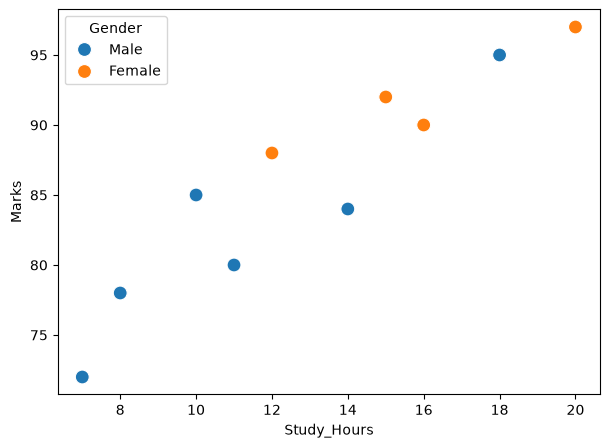

In [37]:
## Best Visualization, Scatter Plot ⭐⭐⭐⭐⭐
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks",
    hue="Gender",
    s=100)

plt.show()

<Axes: xlabel='Study_Hours', ylabel='Marks'>

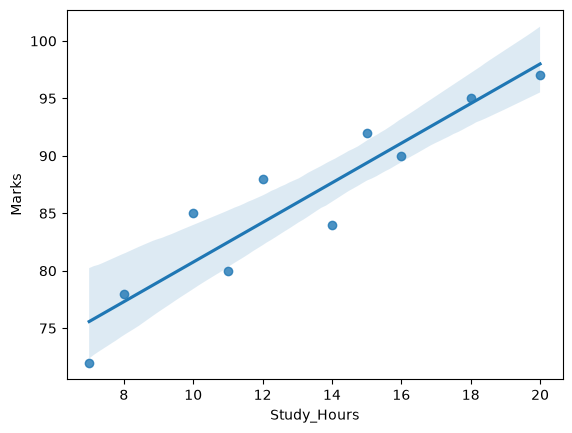

In [ ]:
# Part 2: Regression Plot, Scatter plot + Best-fit line.
sns.regplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)

In [39]:
df["Study_Hours"].corr(
    df["Marks"]
)

np.float64(0.9309452540368619)

In [40]:
df["Study_Hours"].cov(
    df["Marks"]
)

np.float64(31.21111111111111)

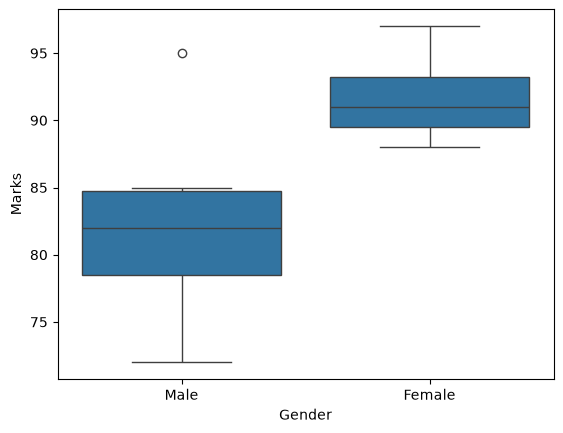

In [41]:
# Numerical vs Categorical, Do male and female students score differently? Box Plot ⭐⭐⭐⭐⭐
sns.boxplot(
    data=df,
    x="Gender",
    y="Marks"
)

plt.show()

<Axes: xlabel='Gender', ylabel='Marks'>

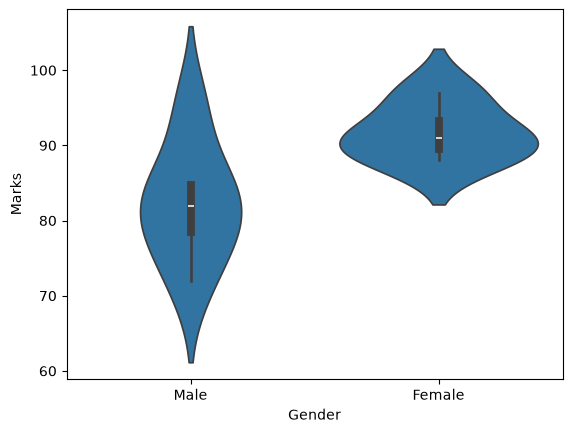

In [42]:
# Violin Plot, Shows both, Distribution Density
sns.violinplot(
    data=df,
    x="Gender",
    y="Marks"
)

<Axes: xlabel='Gender', ylabel='Marks'>

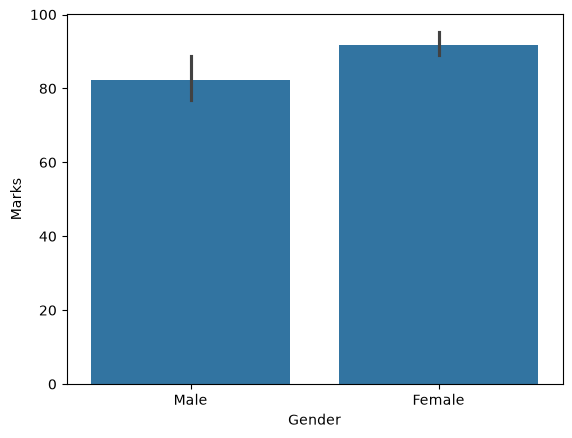

In [43]:
sns.barplot(
    data=df,
    x="Gender",
    y="Marks"
)

In [45]:
# Part 6: Categorical vs Categorical
# Crosstab
df["Pass"] = [
    "Pass","Pass","Fail","Pass","Pass",
    "Pass","Fail","Pass","Pass","Fail"
]

In [46]:
pd.crosstab(
    df["Gender"],
    df["Pass"]
)

Pass,Fail,Pass
Gender,,
Female,0,4
Male,3,3


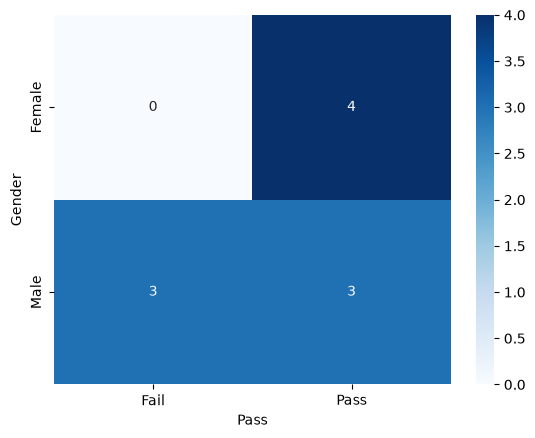

In [47]:
# Heatmap of crosstab
table = pd.crosstab(
    df["Gender"],
    df["Pass"]
)

sns.heatmap(
    table,
    annot=True,
    cmap="Blues"
)

plt.show()

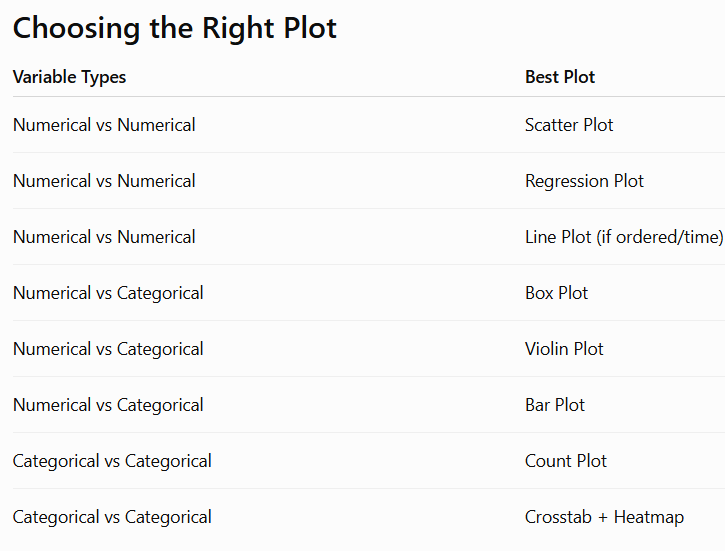

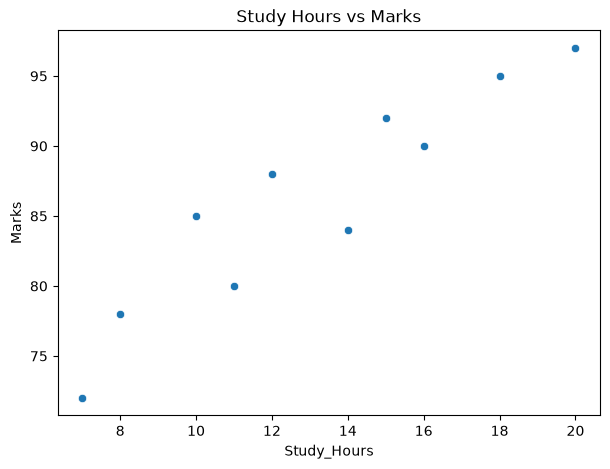

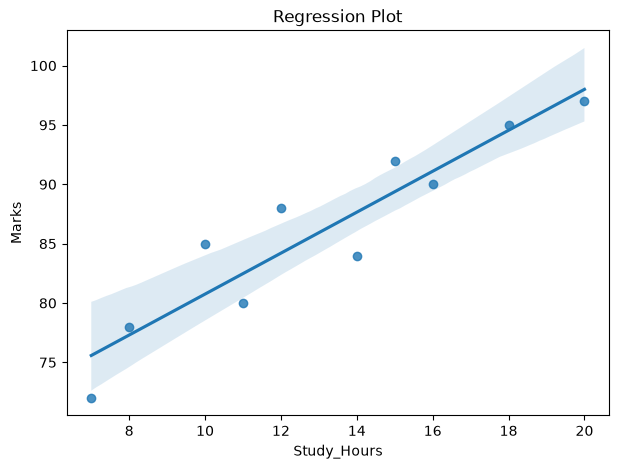

Correlation:
0.9309452540368619


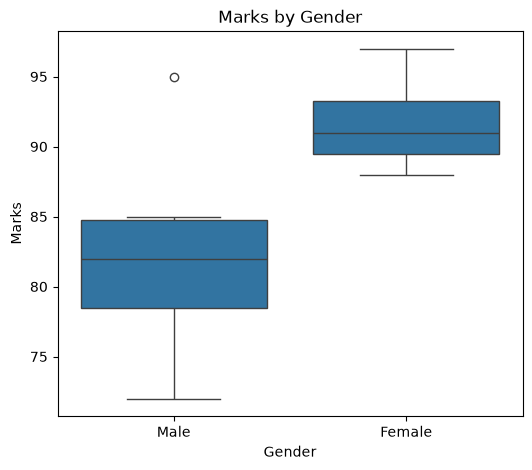

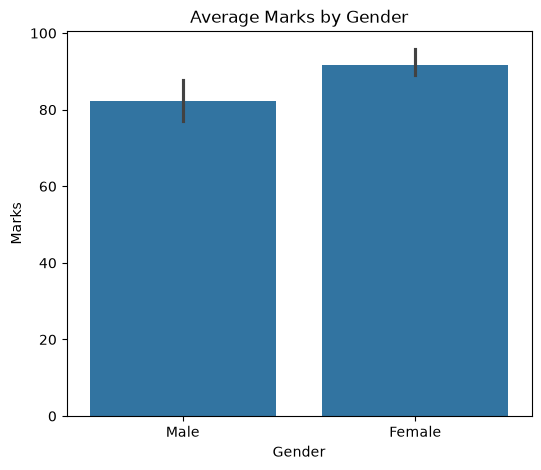

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Gender":["Male","Female","Male","Female",
              "Male","Female","Male","Female",
              "Male","Male"],

    "Study_Hours":[10,15,8,12,18,20,7,16,14,11],

    "Marks":[85,92,78,88,95,97,72,90,84,80]
})

# Scatter Plot
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)

plt.title("Study Hours vs Marks")
plt.show()

# Regression Plot
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)

plt.title("Regression Plot")
plt.show()

# Correlation
print("Correlation:")
print(df["Study_Hours"].corr(df["Marks"]))

# Box Plot
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Marks"
)

plt.title("Marks by Gender")
plt.show()

# Bar Plot
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="Gender",
    y="Marks"
)

plt.title("Average Marks by Gender")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18220\3638032123.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


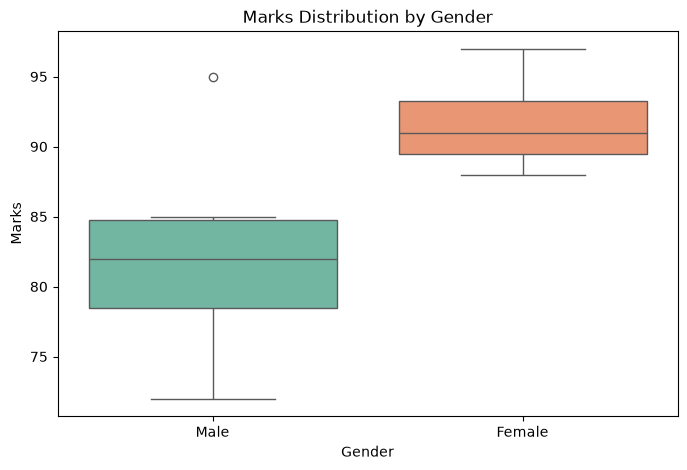

In [49]:
# Create a Box Plot of Marks Grouped by Gender
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Marks",
    palette="Set2"
)

plt.title("Marks Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Marks")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18220\1936370218.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


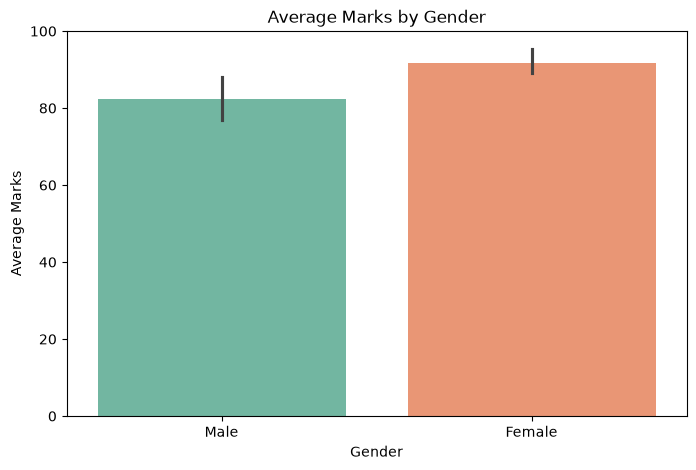

In [50]:
# 2. Create a Bar Plot Showing the Average Marks for Each Gender
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Gender",
    y="Marks",
    palette="Set2"
)

plt.title("Average Marks by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Marks")

plt.show()

Pass    Fail  Pass
Gender            
Female     0     4
Male       3     3


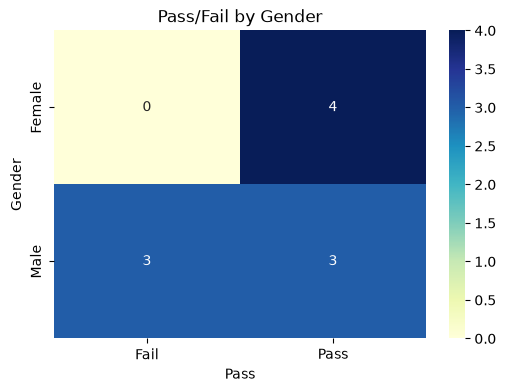

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add Pass column
df["Pass"] = [
    "Pass", "Pass", "Fail", "Pass", "Pass",
    "Pass", "Fail", "Pass", "Pass", "Fail"
]

# Crosstab
cross_tab = pd.crosstab(
    df["Gender"],
    df["Pass"]
)

print(cross_tab)

# Heatmap
plt.figure(figsize=(6, 4))

sns.heatmap(
    cross_tab,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Pass/Fail by Gender")

plt.show()

## Lesson 6: Outlier Detection & Treatment


In [52]:
import pandas as pd

df = pd.DataFrame({
    "Marks":[
        72,75,78,80,82,
        84,85,86,88,90,
        92,95,98,250
    ]
})

print(df)

    Marks
0      72
1      75
2      78
3      80
4      82
5      84
6      85
7      86
8      88
9      90
10     92
11     95
12     98
13    250


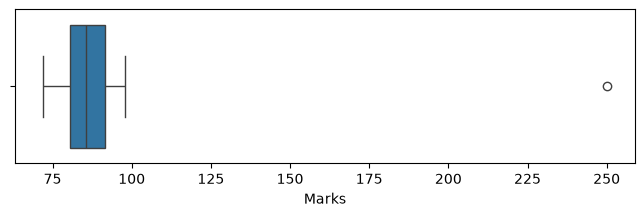

In [53]:
# Method 1: Detect Using Box Plot ⭐⭐⭐⭐⭐, The easiest method.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["Marks"]
)

plt.show()

In [60]:
# Method 2: IQR (Interquartile Range) ⭐⭐⭐⭐⭐

# This is one of the most common methods in data science.
# Step 1: Find Q1
Q1 = df["Marks"].quantile(0.25)
print(Q1)
# Step 2: Find Q3
Q3 = df["Marks"].quantile(0.75)
print(Q3)
IQR = Q3 - Q1
print(IQR)
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(lower, upper)

80.5
91.5
11.0
64.0 108.0


In [61]:
outliers = df[
    (df["Marks"] < lower) |
    (df["Marks"] > upper)
]

print(outliers)

    Marks
13    250


In [ ]:
# Remove Outliers
df_clean = df[
    (df["Marks"] >= lower) &
    (df["Marks"] <= upper)
]
# 250 is removed. Now we have a clean dataset without outliers.

In [ ]:
# Method 3: Z-Score
# Z-score measures, How many standard deviations a value is away from the mean. Z = (x - mean) / std
from scipy.stats import zscore

df["Z"] = zscore(df["Marks"])

print(df)

    Marks         Z
0      72 -0.575298
1      75 -0.505665
2      78 -0.436033
3      80 -0.389611
4      82 -0.343189
5      84 -0.296767
6      85 -0.273557
7      86 -0.250346
8      88 -0.203924
9      90 -0.157502
10     92 -0.111081
11     95 -0.041448
12     98  0.028185
13    250  3.556236


In [64]:
# Detect Outliers Using Z-Score, |Z| > 3
df[
    abs(df["Z"]) > 3
]


,Marks,Z
13,250,3.556236


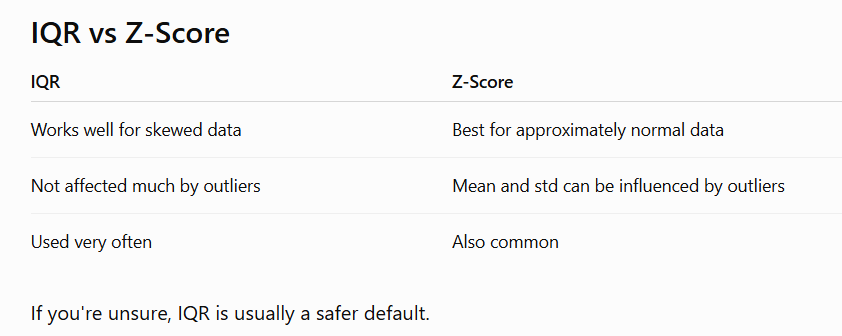

In [ ]:
# Method 4: Capping (Winsorization)
# This keeps the row but limits the extreme value.
# this replaces the outlier with the upper limit (or lower limit if it's a low outlier).
df["Marks"] = df["Marks"].clip(
    lower,
    upper
)

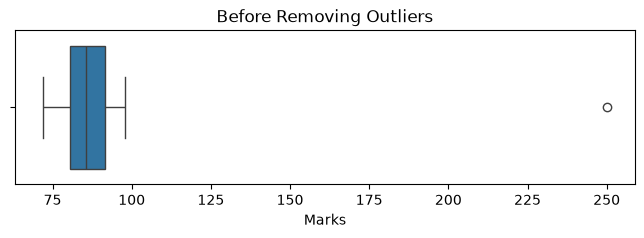

Outliers:
    Marks
13    250


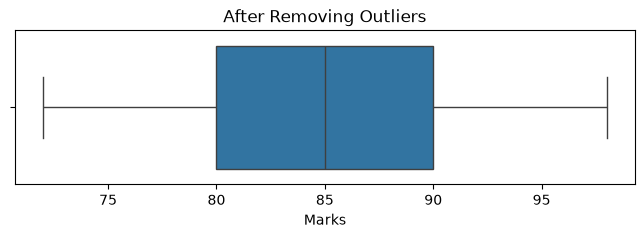

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Marks":[72,75,78,80,82,84,85,86,88,90,92,95,98,250]
})

# Box plot before
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Marks"])
plt.title("Before Removing Outliers")
plt.show()

# IQR
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

# Find outliers
outliers = df[
    (df["Marks"] < lower) |
    (df["Marks"] > upper)
]

print("Outliers:")
print(outliers)

# Remove
df_clean = df[
    (df["Marks"] >= lower) &
    (df["Marks"] <= upper)
]

# Box plot after
plt.figure(figsize=(8,2))
sns.boxplot(x=df_clean["Marks"])
plt.title("After Removing Outliers")
plt.show()

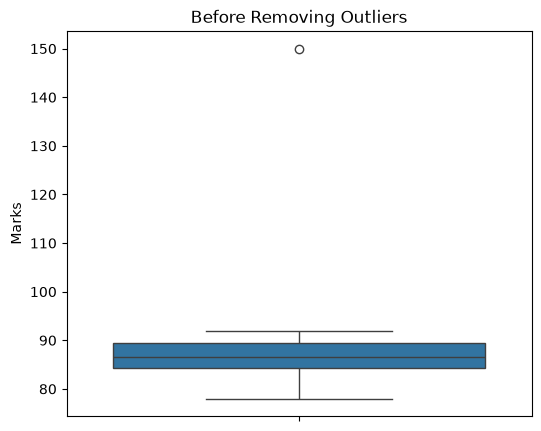

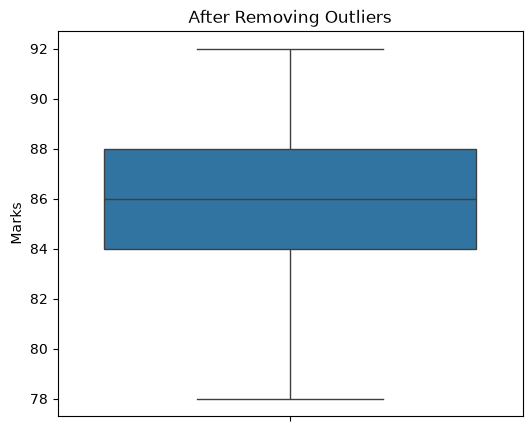

  Student  Marks
0    Abid     78
1    Sara     82
2    John     85
3    Mina     88
4   David     90
5    Alex     84
6    Emma     87
7    Lily     86
8     Tom     92


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame
df = pd.DataFrame({
    "Student": [
        "Abid", "Sara", "John", "Mina", "David",
        "Alex", "Emma", "Lily", "Tom", "Nina"
    ],
    "Marks": [78, 82, 85, 88, 90, 84, 87, 86, 92, 150]
})

# Box plot before removing outliers
plt.figure(figsize=(6,5))
sns.boxplot(y=df["Marks"])
plt.title("Before Removing Outliers")
plt.show()

# IQR Method
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_df = df[
    (df["Marks"] >= lower_bound) &
    (df["Marks"] <= upper_bound)
]

# Box plot after removing outliers
plt.figure(figsize=(6,5))
sns.boxplot(y=clean_df["Marks"])
plt.title("After Removing Outliers")
plt.show()

print(clean_df)


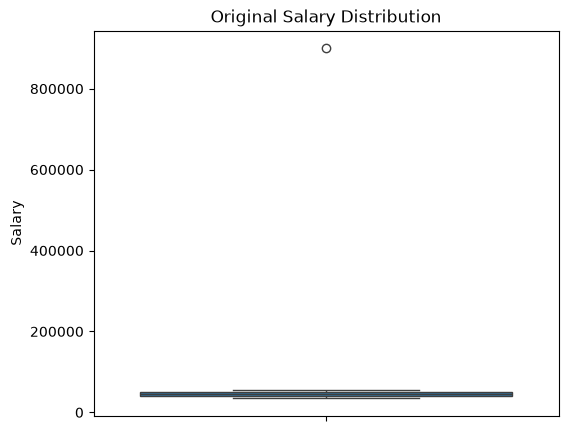

Outliers:
   Salary
9  900000

Original
   Salary
0   35000
1   38000
2   40000
3   42000
4   45000
5   47000
6   50000
7   52000
8   55000
9  900000

Cleaned
   Salary
0   35000
1   38000
2   40000
3   42000
4   45000
5   47000
6   50000
7   52000
8   55000

Capped
   Salary
0   35000
1   38000
2   40000
3   42000
4   45000
5   47000
6   50000
7   52000
8   55000
9   68000


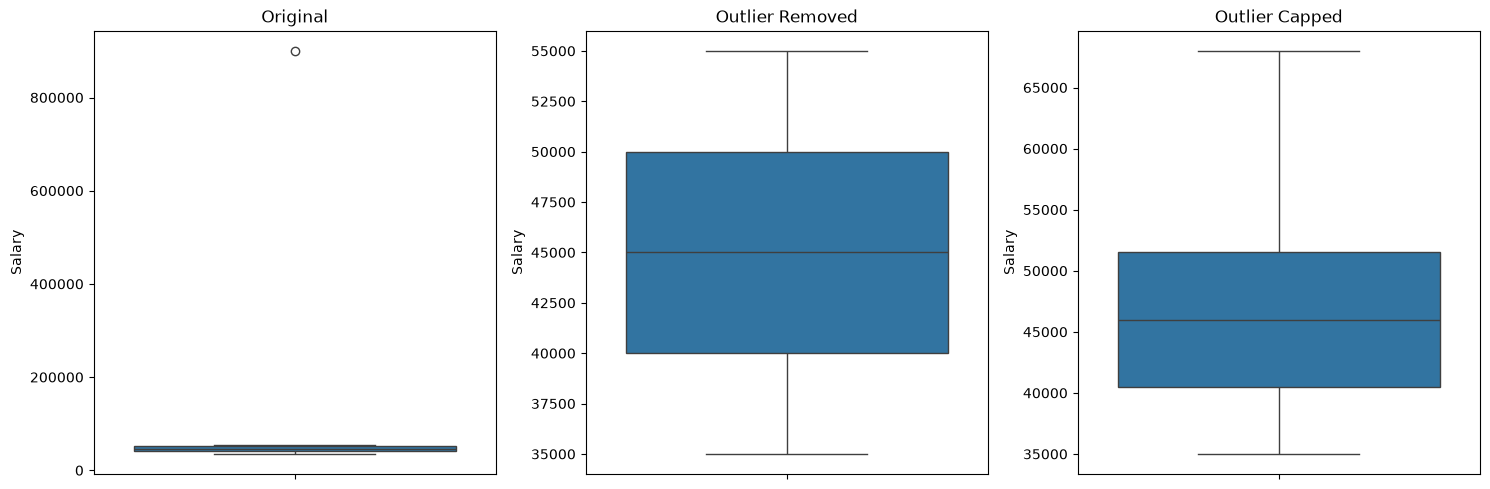

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame
df = pd.DataFrame({
    "Salary": [
        35000,38000,40000,42000,45000,
        47000,50000,52000,55000,900000
    ]
})

# Original Box Plot
plt.figure(figsize=(6,5))
sns.boxplot(y=df["Salary"])
plt.title("Original Salary Distribution")
plt.show()

# IQR
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect Outliers
outliers = df[
    (df["Salary"] < lower_bound) |
    (df["Salary"] > upper_bound)
]

print("Outliers:")
print(outliers)

# Remove Outliers
clean_df = df[
    (df["Salary"] >= lower_bound) &
    (df["Salary"] <= upper_bound)
]

# Cap Outliers
capped_df = df.copy()

capped_df["Salary"] = capped_df["Salary"].clip(
    lower=lower_bound,
    upper=upper_bound
)

# Compare
print("\nOriginal")
print(df)

print("\nCleaned")
print(clean_df)

print("\nCapped")
print(capped_df)

# Three Box Plots
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df["Salary"])
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(y=clean_df["Salary"])
plt.title("Outlier Removed")

plt.subplot(1,3,3)
sns.boxplot(y=capped_df["Salary"])
plt.title("Outlier Capped")

plt.tight_layout()
plt.show()

## Lesson 7: Multivariate Analysis & Correlation Analysis
The word Multivariate means:

Multi = Many
Variable = Columns

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Name":["Abid","Sara","John","Mina","David",
            "Emma","Alex","Sophia","Liam","Noah"],

    "Gender":["Male","Female","Male","Female",
              "Male","Female","Male","Female",
              "Male","Male"],

    "Age":[22,21,23,22,24,21,23,22,24,21],

    "Study_Hours":[10,15,8,12,18,20,7,16,14,11],

    "Attendance":[80,95,70,88,98,99,72,94,90,84],

    "Marks":[85,92,78,88,95,97,72,90,84,80]
})

In [2]:
# Part 1: Correlation Matrix ⭐⭐⭐⭐⭐, This is probably the most important EDA tool.
#Instead of calculating:  df["Study_Hours"].corr(df["Marks"]) one by one
df.corr(numeric_only=True)

,Age,Study_Hours,Attendance,Marks
Age,1.000000,-0.141902,-0.194846,-0.234692
Study_Hours,-0.141902,1.000000,0.960920,0.930945
Attendance,-0.194846,0.960920,1.000000,0.920147
Marks,-0.234692,0.930945,0.920147,1.000000


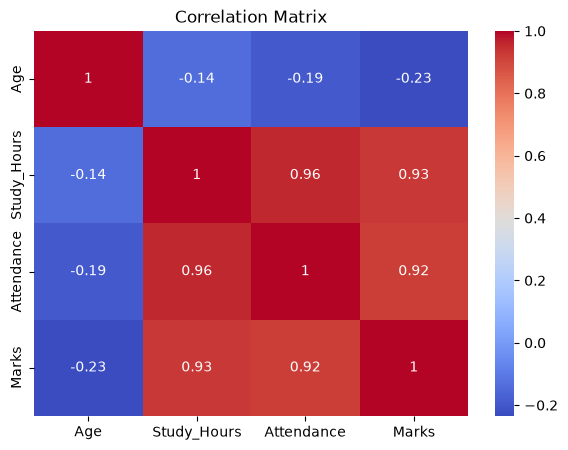

In [3]:
# Part 2: Heatmap ⭐⭐⭐⭐⭐ A correlation matrix is useful,but difficult to read.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

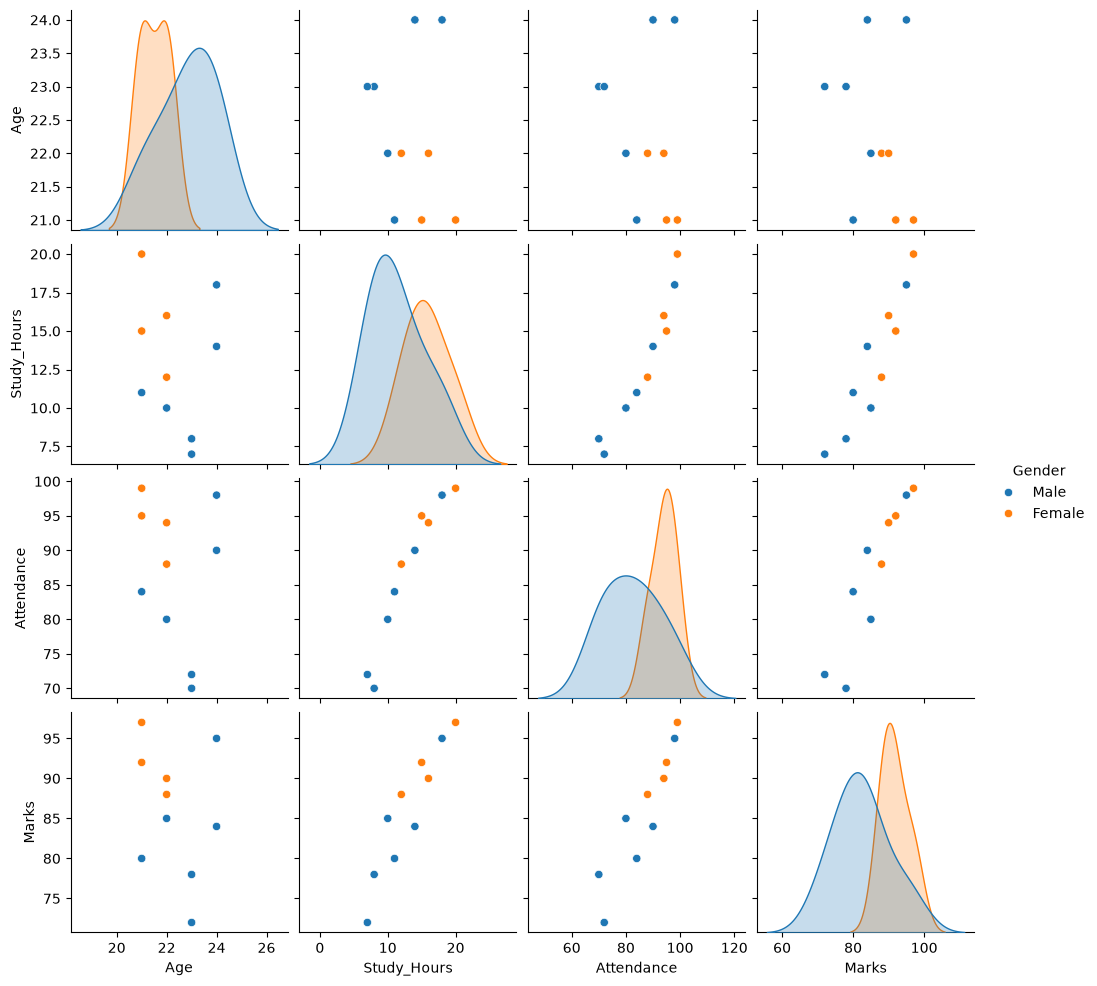

In [5]:
# Part 3: Pair Plot ⭐⭐⭐⭐⭐, One command creates many scatter plots automatically.
sns.pairplot(df,hue="Gender")

In [6]:
# Part 4: GroupBy ⭐⭐⭐⭐⭐ One of the most powerful tools in Pandas.
# What is the average mark for each gender?
df.groupby("Gender")["Marks"].mean()

Gender
Female    91.750000
Male      82.333333
Name: Marks, dtype: float64

<Axes: xlabel='Gender', ylabel='Marks'>

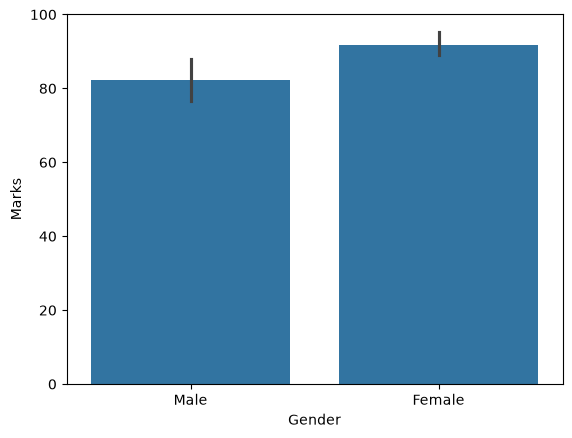

In [11]:
sns.barplot(data=df,x="Gender", y="Marks")

In [12]:
# More examples of GroupBy
df.groupby("Gender")["Study_Hours"].mean()
df.groupby("Gender")["Marks"].max()
df.groupby("Gender")["Marks"].min()
# group by multiple statistics
df.groupby("Gender")["Marks"].agg(
    ["mean","max","min","std"]
)
# group by multiple columns
df.groupby(
    ["Gender","Age"]
)["Marks"].mean()

Gender  Age
Female  21     94.5
        22     89.0
Male    21     80.0
        22     85.0
        23     75.0
        24     89.5
Name: Marks, dtype: float64

In [13]:
# Part 5: Pivot Table ⭐⭐⭐⭐⭐ Pivot tables summarize data beautifully.
pd.pivot_table(
    df,
    values="Marks",
    index="Gender",
    aggfunc="mean"
)

,Marks
Gender,
Female,91.750000
Male,82.333333


In [14]:
# Advanced Pivot Table
pd.pivot_table(
    df,
    values="Marks",
    index="Gender",
    columns="Age",
    aggfunc="mean"
)

Age,21,22,23,24
Gender,,,,
Female,94.5,89.0,NaN,NaN
Male,80.0,85.0,75.0,89.5


In [21]:
# Crosstab (frequency table) ⭐⭐⭐⭐⭐
df["Pass"]=[
"Pass","Pass","Fail","Pass","Pass",
"Pass","Fail","Pass","Pass","Fail"
]
pd.crosstab(
    df["Gender"],
    df["Pass"]
)

Pass,Fail,Pass
Gender,,
Female,0,4
Male,3,3


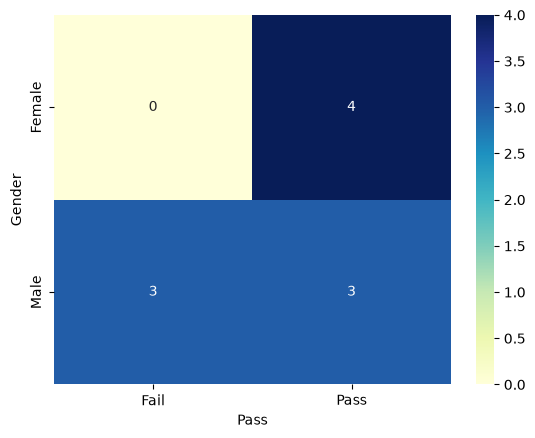

In [22]:
table = pd.crosstab(
    df["Gender"],
    df["Pass"]
)

sns.heatmap(
    table,
    annot=True,
    cmap="YlGnBu"
)

plt.show()

                  Age  Study_Hours  Attendance     Marks
Age          1.000000    -0.141902   -0.194846 -0.234692
Study_Hours -0.141902     1.000000    0.960920  0.930945
Attendance  -0.194846     0.960920    1.000000  0.920147
Marks       -0.234692     0.930945    0.920147  1.000000


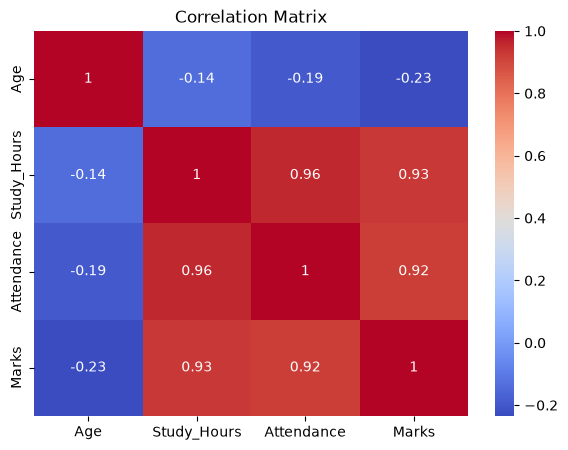

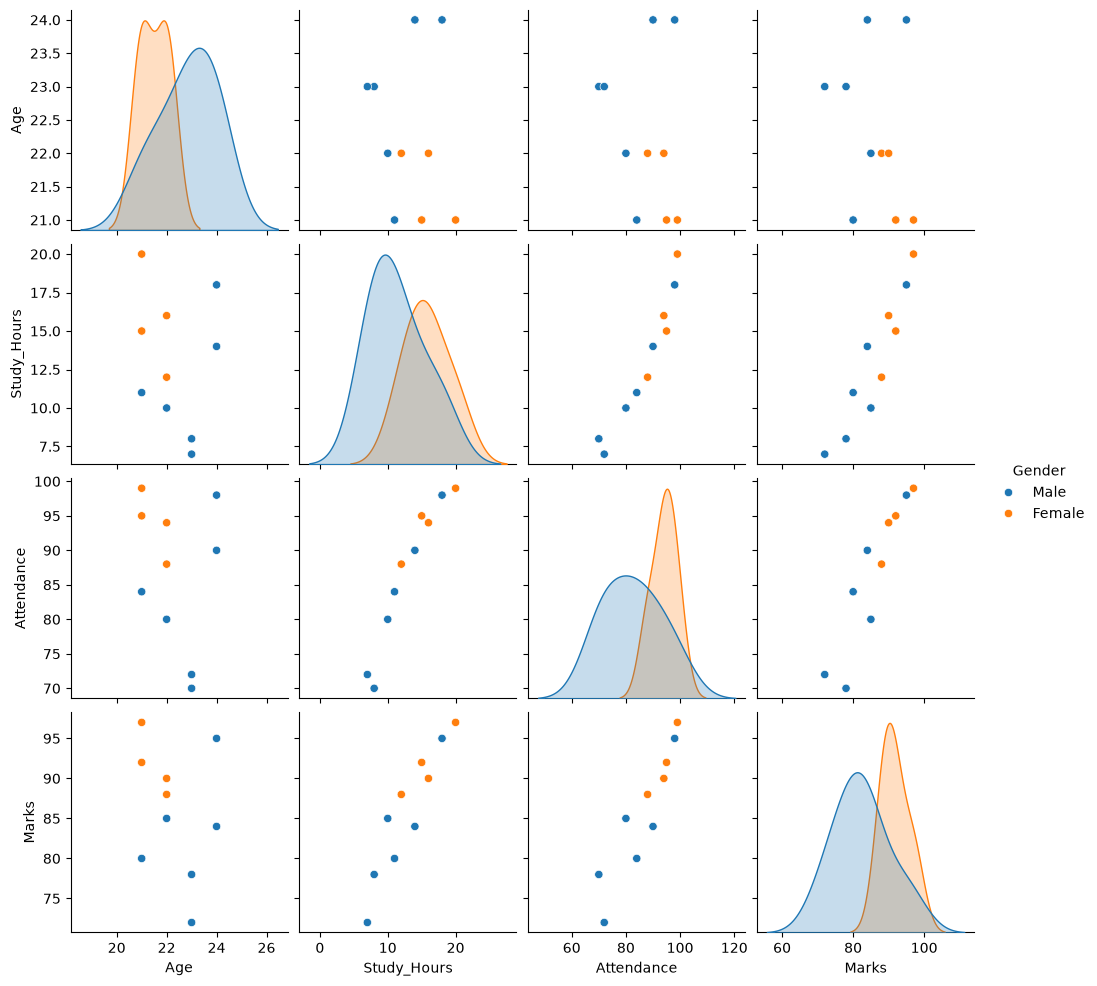

Gender
Female    91.750000
Male      82.333333
Name: Marks, dtype: float64
            Marks
Gender           
Female  91.750000
Male    82.333333


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Gender":["Male","Female","Male","Female",
              "Male","Female","Male","Female",
              "Male","Male"],

    "Age":[22,21,23,22,24,21,23,22,24,21],

    "Study_Hours":[10,15,8,12,18,20,7,16,14,11],

    "Attendance":[80,95,70,88,98,99,72,94,90,84],

    "Marks":[85,92,78,88,95,97,72,90,84,80]
})

# Correlation Matrix
print(df.corr(numeric_only=True))

# Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

# Pair Plot
sns.pairplot(
    df,
    hue="Gender"
)
plt.show()

# GroupBy
print(
    df.groupby("Gender")["Marks"].mean()
)

# Pivot Table
print(
    pd.pivot_table(
        df,
        values="Marks",
        index="Gender",
        aggfunc="mean"
    )
)

                  Age  Study_Hours     Marks
Age          1.000000     0.209615  0.026657
Study_Hours  0.209615     1.000000  0.967271
Marks        0.026657     0.967271  1.000000


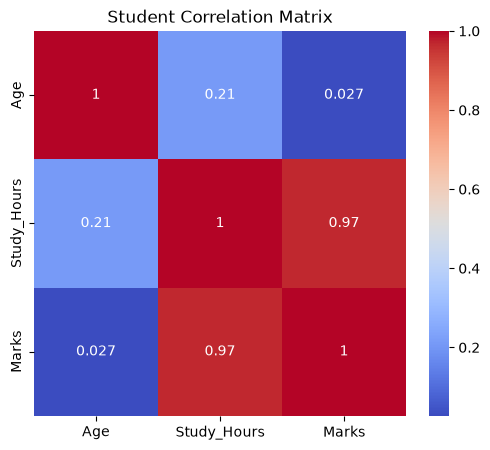

In [24]:
df = pd.DataFrame({
    "Age":[22,21,23,22,24],
    "Study_Hours":[10,15,8,12,18],
    "Marks":[85,92,78,88,95]
})
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr = df.corr(numeric_only=True)

print(corr)
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Student Correlation Matrix")

plt.show()

## ## Lesson 8: Complete EDA Project (Step-by-Step Like a Real Data Scientist)
## The Professional EDA Workflow ,Whenever you receive a new dataset:
Load Data
      ↓
Inspect Dataset
      ↓
Check Data Types
      ↓
Check Missing Values
      ↓
Check Duplicates
      ↓
Clean Data
      ↓
Univariate Analysis
      ↓
Bivariate Analysis
      ↓
Outlier Detection
      ↓
Correlation Analysis
      ↓
Draw Conclusions

If you memorize this workflow, you'll know what to do with any dataset.

In [26]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name":["Abid","Sara","John","Mina","David",
            "Emma","Alex","Sophia","Liam","Noah"],

    "Gender":["Male","Female","Male","Female",
              "Male","Female","Male","Female",
              "Male","Male"],

    "Age":[22,21,23,np.nan,24,21,23,22,24,21],

    "Study_Hours":[10,15,8,12,18,20,7,16,np.nan,11],

    "Attendance":[80,95,70,88,98,99,72,94,90,84],

    "Marks":[85,92,78,88,95,97,72,90,84,350]
})

In [27]:
df.head()

,Name,Gender,Age,Study_Hours,Attendance,Marks
0,Abid,Male,22.0,10.0,80,85
1,Sara,Female,21.0,15.0,95,92
2,John,Male,23.0,8.0,70,78
3,Mina,Female,NaN,12.0,88,88
4,David,Male,24.0,18.0,98,95


In [28]:
df.tail()

,Name,Gender,Age,Study_Hours,Attendance,Marks
5,Emma,Female,21.0,20.0,99,97
6,Alex,Male,23.0,7.0,72,72
7,Sophia,Female,22.0,16.0,94,90
8,Liam,Male,24.0,NaN,90,84
9,Noah,Male,21.0,11.0,84,350


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         10 non-null     str    
 1   Gender       10 non-null     str    
 2   Age          9 non-null      float64
 3   Study_Hours  9 non-null      float64
 4   Attendance   10 non-null     int64  
 5   Marks        10 non-null     int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 612.0 bytes


In [30]:
df.describe()

,Age,Study_Hours,Attendance,Marks
count,9.000000,9.0,10.000000,10.000000
mean,22.333333,13.0,87.000000,113.100000
std,1.224745,4.5,10.327956,83.582893
min,21.000000,7.0,70.000000,72.000000
25%,21.000000,10.0,81.000000,84.250000
50%,22.000000,12.0,89.000000,89.000000
75%,23.000000,16.0,94.750000,94.250000
max,24.000000,20.0,99.000000,350.000000


In [31]:
df.isnull().sum()

Name           0
Gender         0
Age            1
Study_Hours    1
Attendance     0
Marks          0
dtype: int64

In [32]:
df.isnull().sum(axis=1)

0    0
1    0
2    0
3    1
4    0
5    0
6    0
7    0
8    1
9    0
dtype: int64

In [33]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

df["Study_Hours"] = df["Study_Hours"].fillna(
    df["Study_Hours"].mean()
)

In [ ]:
df.duplicated().sum() # chek for duplicates if exist

np.int64(0)

In [ ]:
df = df.drop_duplicates() # Remove duplicates

In [36]:
df.dtypes

Name               str
Gender             str
Age            float64
Study_Hours    float64
Attendance       int64
Marks            int64
dtype: object

In [41]:
df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
) # if age== object, convert to numeric, if not possible, set to NaN

In [42]:
df.dtypes

Name               str
Gender             str
Age            float64
Study_Hours    float64
Attendance       int64
Marks            int64
dtype: object

In [43]:
## Step 8: Univariate Analysis
df["Marks"].describe()

count     10.000000
mean     113.100000
std       83.582893
min       72.000000
25%       84.250000
50%       89.000000
75%       94.250000
max      350.000000
Name: Marks, dtype: float64

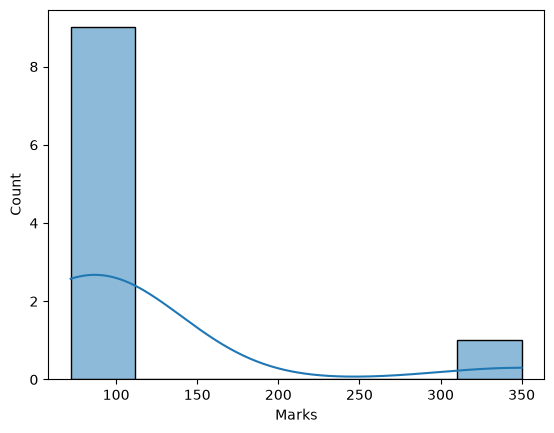

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="Marks",
    kde=True
)

plt.show()

In [45]:
# Check Categorical Variables
df["Gender"].value_counts()

Gender
Male      6
Female    4
Name: count, dtype: int64

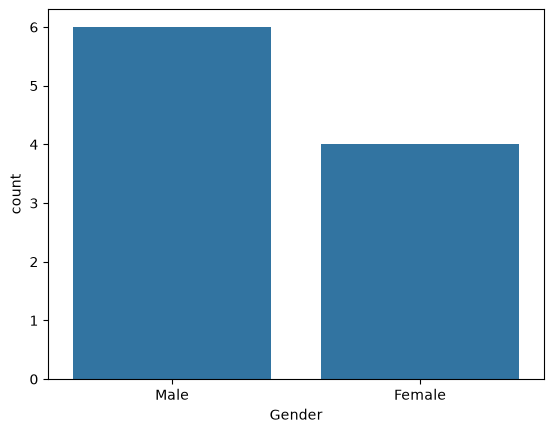

In [46]:
sns.countplot(
    data=df,
    x="Gender"
)

plt.show()

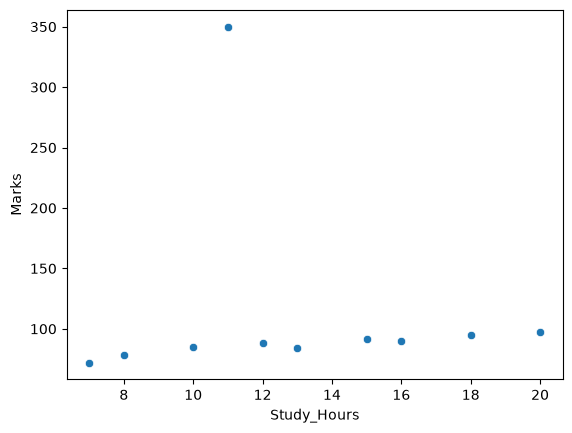

In [47]:
#Step 9: Bivariate Analysis
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)

plt.show()

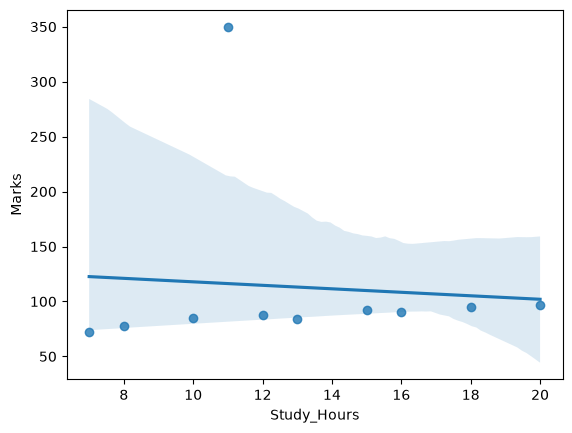

In [48]:
sns.regplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)

plt.show()

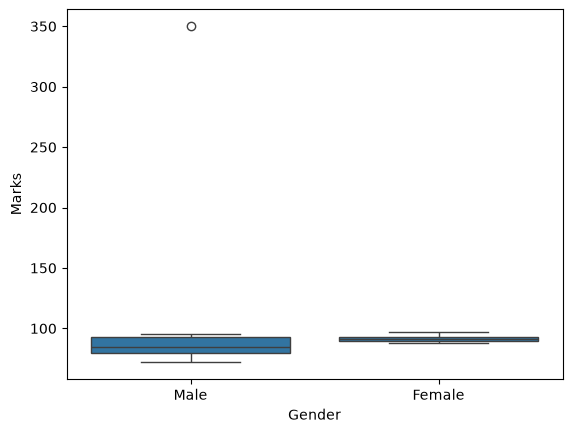

In [49]:
sns.boxplot(
    data=df,
    x="Gender",
    y="Marks"
)

plt.show()

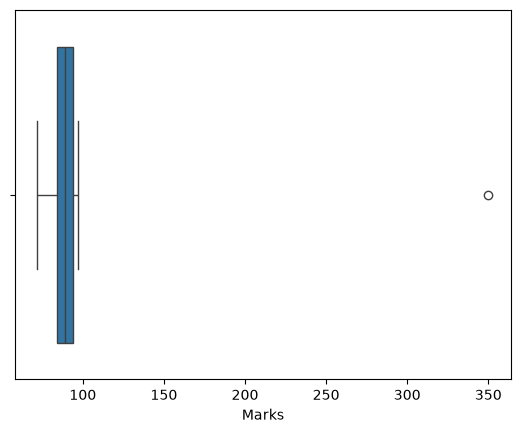

In [50]:
sns.boxplot(
    x=df["Marks"]
)

plt.show()

In [52]:
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[
    (df["Marks"] < lower) |
    (df["Marks"] > upper)
]

print(outliers)

   Name Gender   Age  Study_Hours  Attendance  Marks
9  Noah   Male  21.0         11.0          84    350


In [53]:
df.corr(numeric_only=True)


,Age,Study_Hours,Attendance,Marks
Age,1.000000,-0.180692,-0.194846,-0.424544
Study_Hours,-0.180692,1.000000,0.955979,-0.080526
Attendance,-0.194846,0.955979,1.000000,-0.017505
Marks,-0.424544,-0.080526,-0.017505,1.000000


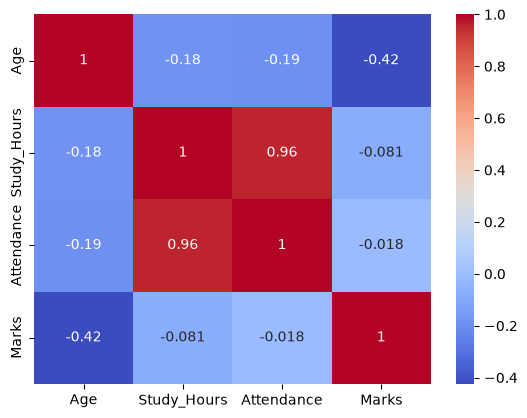

In [54]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

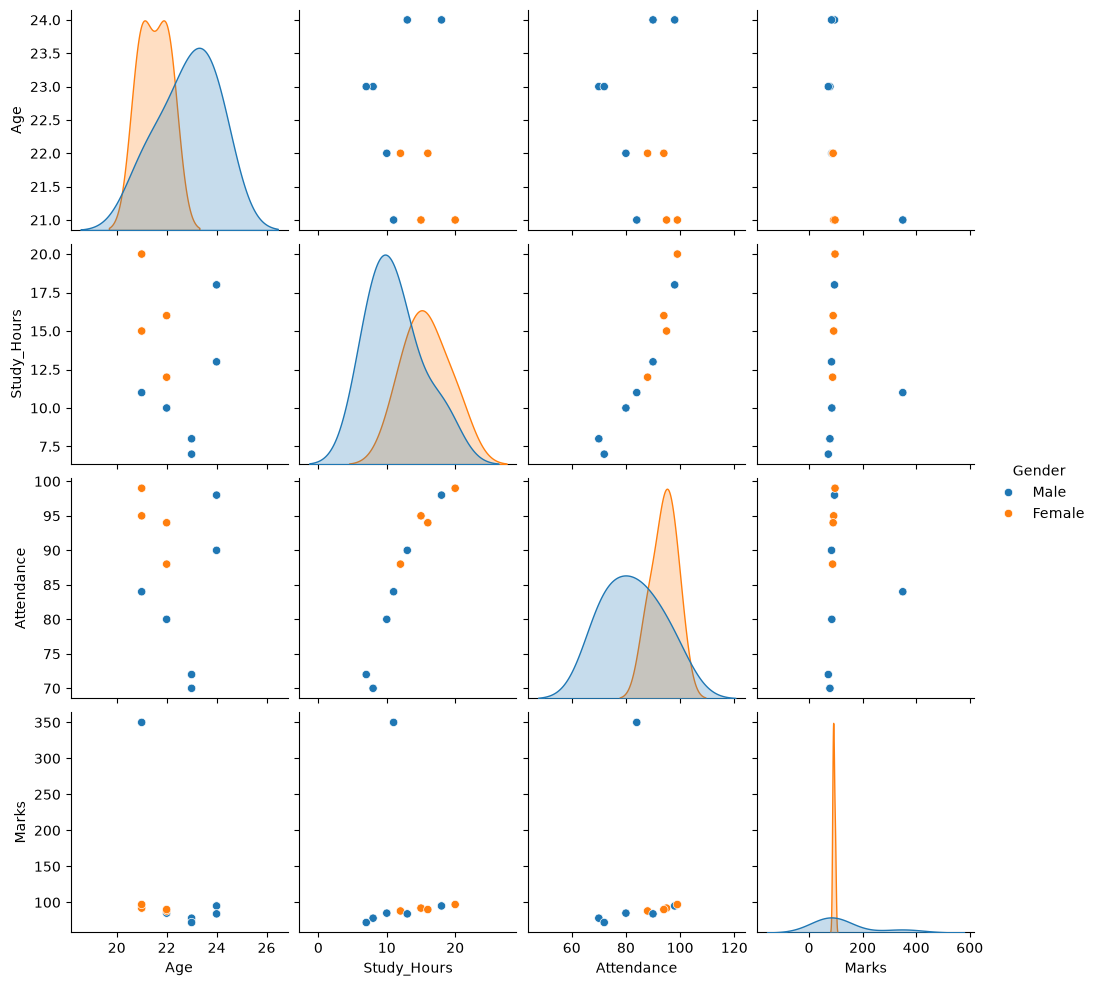

In [55]:
sns.pairplot(
    df,
    hue="Gender"
)

plt.show()

In [56]:
df.groupby("Gender")["Marks"].mean()

Gender
Female     91.750000
Male      127.333333
Name: Marks, dtype: float64

In [57]:
df.groupby("Gender")["Attendance"].mean()

Gender
Female    94.000000
Male      82.333333
Name: Attendance, dtype: float64

In [58]:
pd.pivot_table(
    df,
    values="Marks",
    index="Gender",
    aggfunc="mean"
)

,Marks
Gender,
Female,91.750000
Male,127.333333


# Load
pd.read_csv(...)

# First look
df.head()
df.tail()

# Information
df.info()

# Statistics
df.describe()

# Missing values
df.isnull().sum()

# Duplicates
df.duplicated().sum()

# Data types
df.dtypes

# Univariate
df.describe()
sns.histplot(...)
sns.boxplot(...)
sns.countplot(...)

# Bivariate
sns.scatterplot(...)
sns.regplot(...)
sns.boxplot(...)

# Correlation
df.corr(numeric_only=True)
sns.heatmap(...)

# Pair Plot
sns.pairplot(...)

# GroupBy
df.groupby(...)

# Pivot Table
pd.pivot_table(...)

In [ ]:
# Project: Student Performance Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.DataFrame({
    "Name": [
        "Abid", "Sara", "John", "Mina", "David",
        "Emma", "Alex", "Lily", "Tom", "Nina"
    ],
    "Age": [22, 21, 23, 22, np.nan, 20, 21, 22, 23, 21],
    "Gender": [
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female"
    ],
    "Study_Hours": [10, 15, 8, 12, 20, 18, 14, np.nan, 16, 11],
    "Attendance": [90, 95, 80, 88, 96, 92, 85, 91, 89, np.nan],
    "Marks": [85, 92, 78, 88, 95, 91, 84, 89, 90, np.nan]
})

In [60]:
print(df.head())

print("\nInformation:")
print(df.info())

print("\nStatistics:")
print(df.describe())

    Name   Age  Gender  Study_Hours  Attendance  Marks
0   Abid  22.0    Male         10.0        90.0   85.0
1   Sara  21.0  Female         15.0        95.0   92.0
2   John  23.0    Male          8.0        80.0   78.0
3   Mina  22.0  Female         12.0        88.0   88.0
4  David   NaN    Male         20.0        96.0   95.0

Information:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         10 non-null     str    
 1   Age          9 non-null      float64
 2   Gender       10 non-null     str    
 3   Study_Hours  9 non-null      float64
 4   Attendance   9 non-null      float64
 5   Marks        9 non-null      float64
dtypes: float64(4), str(2)
memory usage: 612.0 bytes
None

Statistics:
             Age  Study_Hours  Attendance      Marks
count   9.000000     9.000000    9.000000   9.000000
mean   21.666667    13.777778   89.555556  88.000000


In [61]:
print(df.isnull().sum())

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].median())
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())
df["Marks"] = df["Marks"].fillna(df["Marks"].median())

print("\nMissing Values After Filling:")
print(df.isnull().sum())

Name           0
Age            1
Gender         0
Study_Hours    1
Attendance     1
Marks          1
dtype: int64

Missing Values After Filling:
Name           0
Age            0
Gender         0
Study_Hours    0
Attendance     0
Marks          0
dtype: int64


In [62]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


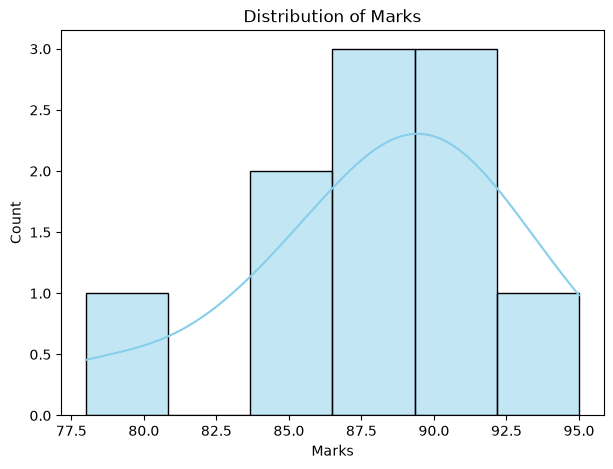

In [63]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Marks"],
    bins=6,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Marks")
plt.show()

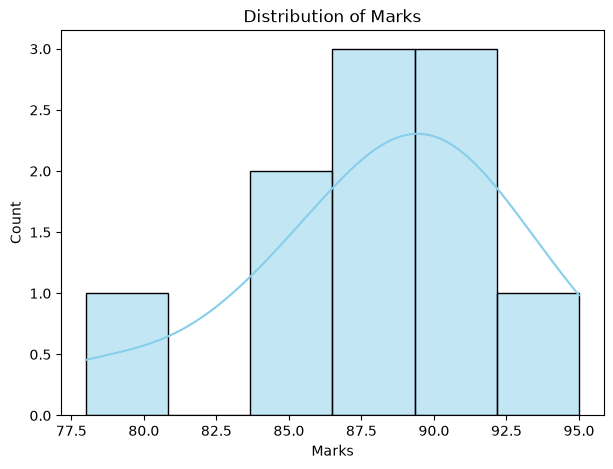

In [64]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Marks"],
    bins=6,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Marks")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_7780\2618167887.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


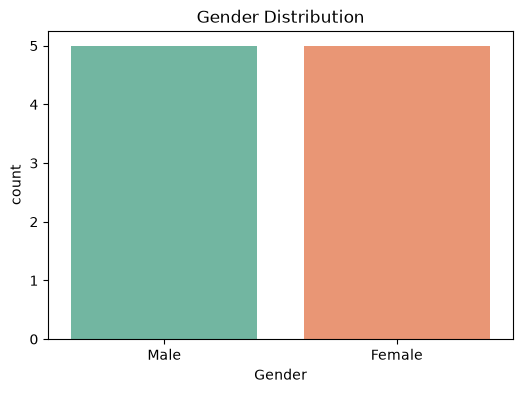

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    palette="Set2"
)

plt.title("Gender Distribution")
plt.show()

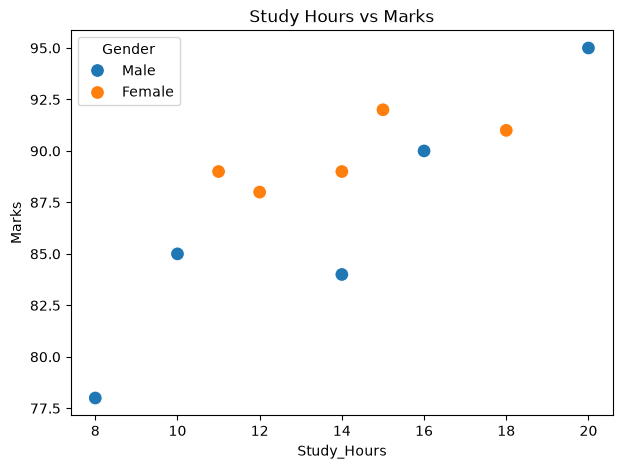

In [66]:
# 5. Bivariate Analysis
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks",
    hue="Gender",
    s=100
)

plt.title("Study Hours vs Marks")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_7780\2150353612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


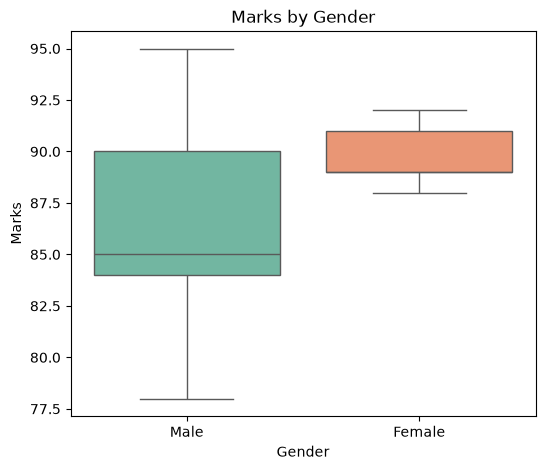

In [67]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Marks",
    palette="Set2"
)

plt.title("Marks by Gender")
plt.show()

In [68]:
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Marks"] < lower) |
    (df["Marks"] > upper)
]

print("Outliers:")
print(outliers)

Outliers:
   Name   Age Gender  Study_Hours  Attendance  Marks
2  John  23.0   Male          8.0        80.0   78.0


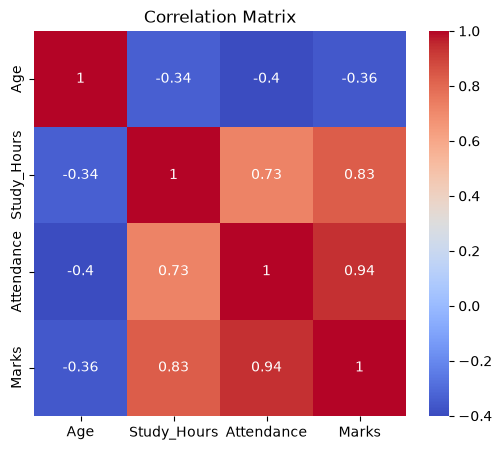

In [69]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

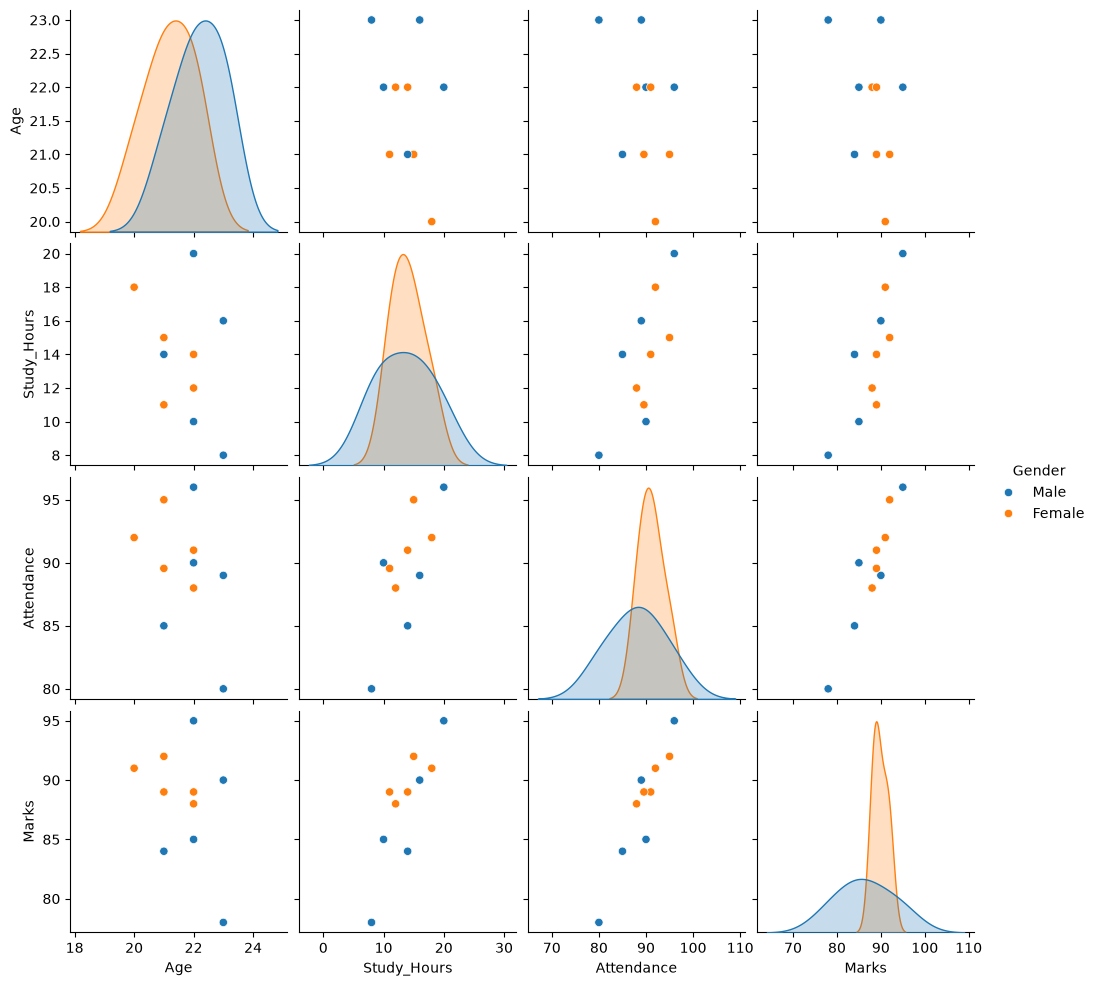

In [70]:
sns.pairplot(
    df,
    hue="Gender"
)

plt.show()

In [71]:
print(df.groupby("Gender")["Marks"].mean())

Gender
Female    89.8
Male      86.4
Name: Marks, dtype: float64


In [72]:
print(df.groupby("Gender")["Attendance"].mean())

Gender
Female    91.111111
Male      88.000000
Name: Attendance, dtype: float64


In [73]:
summary = df.groupby("Gender")[["Marks", "Attendance"]].mean()

print(summary)

        Marks  Attendance
Gender                   
Female   89.8   91.111111
Male     86.4   88.000000


10. Five Conclusions

Based on the example dataset, you could write:

Conclusion 1

The histogram shows that most students scored between 80 and 95 marks, indicating generally good academic performance.

Conclusion 2

The scatter plot suggests a positive relationship between Study_Hours and Marks. Students who studied more hours generally achieved higher marks.

Conclusion 3

The box plot indicates that female students have slightly higher median marks than male students in this dataset.

Conclusion 4

The correlation heatmap shows that Study_Hours and Marks have a strong positive correlation, meaning increased study time is associated with higher marks.

Conclusion 5

The IQR analysis found no significant outliers in the Marks column, indicating that the marks are fairly consistent without extreme values.